In [16]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_samples = 10000

user_ids = [f'U{str(i).zfill(5)}' for i in range(n_samples)]

data = {
    'user_id': user_ids,
    'user_age': np.random.randint(18, 80, n_samples),
    'tenure_months': np.random.randint(1, 73, n_samples),
    'total_purchases': np.random.randint(1, 200, n_samples),
    'avg_purchase_value': np.random.uniform(10, 500, n_samples),
    'last_purchase_days': np.random.randint(1, 365, n_samples),
    'support_tickets': np.random.randint(0, 10, n_samples),
    'complaints': np.random.randint(0, 6, n_samples),
    'discount_used': np.random.choice([0,1], n_samples),
    'email_open_rate': np.random.uniform(0,1,n_samples),
    'app_visits_per_week': np.random.randint(0,30,n_samples),
    'payment_delays': np.random.randint(0,5,n_samples)
}

df = pd.DataFrame(data)

# STRONG churn logic
df['churn'] = (
    (df['last_purchase_days'] > 120) |
    (df['complaints'] > 3) |
    (df['payment_delays'] > 2) |
    ((df['tenure_months'] < 6) & (df['support_tickets'] > 4))
).astype(int)

df.to_csv("churn_dataset.csv", index=False)

print("Dataset created")
print(df.head())
print("Churn rate:", df['churn'].mean()*100)

Dataset created
  user_id  user_age  tenure_months  total_purchases  avg_purchase_value  \
0  U00000        56             26              102           82.088969   
1  U00001        69             61               69          276.432089   
2  U00002        46             37              133          199.173287   
3  U00003        32             23              189          226.843236   
4  U00004        60             40              166          266.564281   

   last_purchase_days  support_tickets  complaints  discount_used  \
0                 200                6           4              0   
1                 106                1           5              0   
2                 275                5           1              0   
3                 289                4           5              1   
4                 258                5           2              0   

   email_open_rate  app_visits_per_week  payment_delays  churn  
0         0.041520                   26              

### Hyperparameter Tuning with GridSearchCV

I will now perform hyperparameter tuning using `GridSearchCV` to find the best parameters for the XGBoost model. This process involves defining a grid of hyperparameters and searching for the combination that yields the highest accuracy (or another chosen metric) on a validation set.

In [6]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'max_depth': [3, 5, 7],           # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2],# Step size shrinkage to prevent overfitting
    'subsample': [0.7, 0.9],          # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.9]    # Subsample ratio of columns when constructing each tree
}

# Initialize XGBClassifier again for tuning
# eval_metric is set for binary classification
xgb_tuned = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Initialize GridSearchCV
# We'll use 'accuracy' as the scoring metric for simplicity, but 'roc_auc' or 'f1' might be better for imbalanced datasets
grid_search = GridSearchCV(estimator=xgb_tuned, param_grid=param_grid,
                           scoring='accuracy', cv=3, verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best accuracy found:", grid_search.best_score_)

# Get the best model
best_xgb_model = grid_search.best_estimator_

print("Tuned XGBoost model trained successfully!")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters found: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}
Best accuracy found: 0.6742599317706613
Tuned XGBoost model trained successfully!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:55:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Evaluate the Tuned Model

Now, let's evaluate the performance of the XGBoost model with the optimized hyperparameters on the test set.

In [7]:
# Make predictions on the test set with the best model
y_pred_tuned = best_xgb_model.predict(X_test)

# Evaluate the tuned model
print("\n--- Tuned Model Evaluation ---")
print("Accuracy Score (Tuned Model):", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report (Tuned Model):\n", classification_report(y_test, y_pred_tuned))


--- Tuned Model Evaluation ---
Accuracy Score (Tuned Model): 0.61

Classification Report (Tuned Model):
               precision    recall  f1-score   support

           0       0.57      0.49      0.53       134
           1       0.63      0.70      0.67       166

    accuracy                           0.61       300
   macro avg       0.60      0.60      0.60       300
weighted avg       0.61      0.61      0.61       300



In [3]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Prepare the data
X = df_churn.drop(['user_id', 'churn'], axis=1)  # Features
y = df_churn['churn']  # Target variable

# Convert categorical features if any, although in this synthetic dataset they are numerical.
# For XGBoost, it's often beneficial to convert non-numeric features to one-hot encoding.
# However, given the synthetic nature and current all-numeric feature set (except user_id), this step is simplified.

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (700, 11)
Testing set shape: (300, 11)


Now, let's train the XGBoost Classifier.

In [4]:
# Initialize and train the XGBoost Classifier
# Using default parameters for simplicity. Hyperparameter tuning could improve performance.
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:53:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained successfully!


Finally, let's evaluate the model's performance on the test set.

In [5]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation ---")
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


--- Model Evaluation ---
Accuracy Score: 0.6033333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.54      0.55       134
           1       0.64      0.65      0.64       166

    accuracy                           0.60       300
   macro avg       0.60      0.60      0.60       300
weighted avg       0.60      0.60      0.60       300



Dataset Shape: (10000, 13)
  user_id  user_age  tenure_months  total_purchases  avg_purchase_value  \
0  U00000        56             26              102           82.088969   
1  U00001        69             61               69          276.432089   
2  U00002        46             37              133          199.173287   
3  U00003        32             23              189          226.843236   
4  U00004        60             40              166          266.564281   

   last_purchase_days  support_tickets  complaints  discount_used  \
0                 200                6           4              0   
1                 106                1           5              0   
2                 275                5           1              0   
3                 289                4           5              1   
4                 258                5           2              0   

   email_open_rate  app_visits_per_week  payment_delays  churn  
0         0.041520                   26   

<Figure size 1000x600 with 0 Axes>

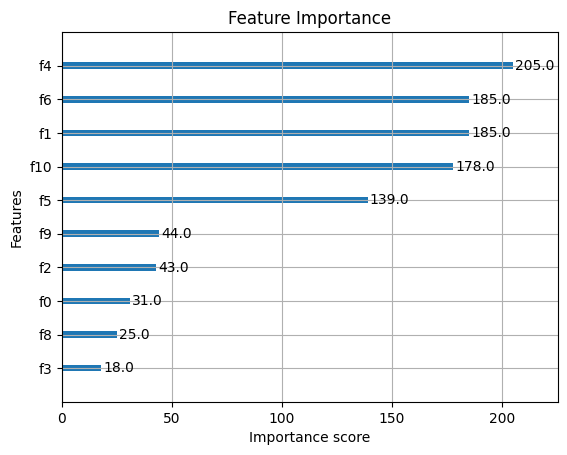

In [17]:
# ==============================
# CHURN PREDICTION USING XGBOOST
# COMPLETE COLAB SCRIPT
# ==============================

# Install XGBoost if not installed
!pip install xgboost

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, plot_importance

# ==============================
# 1. LOAD DATASET
# ==============================

# Upload CSV in Colab or give path
df = pd.read_csv("churn_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ==============================
# 2. DATA PREPROCESSING
# ==============================

# Remove unnecessary column
if 'user_id' in df.columns:
    df = df.drop(columns=['user_id'])

# Convert categorical columns to numeric
df = pd.get_dummies(df, drop_first=True)

print("\nAfter Encoding Shape:", df.shape)

# ==============================
# 3. FEATURE & TARGET SPLIT
# ==============================

X = df.drop('churn', axis=1)
y = df['churn']

# ==============================
# 4. TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ==============================
# 5. FEATURE SCALING
# ==============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 6. HYPERPARAMETER TUNING
# ==============================

param_grid = {
    'max_depth': [3,5,7],
    'learning_rate': [0.01,0.05,0.1],
    'n_estimators': [100,200,300],
    'subsample': [0.7,0.8,1],
    'colsample_bytree': [0.7,0.8,1]
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

# ==============================
# 7. TRAIN BEST MODEL
# ==============================

best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

print("\nXGBoost Model Trained Successfully!")

# ==============================
# 8. PREDICTION
# ==============================

y_pred = best_model.predict(X_test)

# ==============================
# 9. MODEL EVALUATION
# ==============================

print("\n===== MODEL PERFORMANCE =====")

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ==============================
# 10. FEATURE IMPORTANCE
# ==============================

plt.figure(figsize=(10,6))
plot_importance(best_model)
plt.title("Feature Importance")
plt.show()

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("churn_dataset.csv")

X = df.drop(['user_id','churn'], axis=1)
y = df['churn']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred))

Accuracy: 1.0
